In [1]:
import pandas as pd
from pathlib import Path
import os
from datetime import datetime
from tqdm import tqdm

In [25]:
def parseFileName(fileName):

    #removing file type first
    fileNameStub = fileName.split('.')[0]

    nameSegs = fileNameStub.split('_')

    device = nameSegs[0]

    if device == 'steth':
        # filename is steth_year_month_date etc, combining all date/time params into one identifier
        # first convert to tuple then join tuple elements
        identifierTuple = tuple(nameSegs[1:])
        identifier = ''.join(identifierTuple)
        
        position = 'NA' # no position information for Litt 3200 device
        rep = 'NA'
    else:
        # filename is trunc_YYYY-MM-DD-HH-MM-SS-Postion_rep
        datepos = nameSegs[1].split('-')
        
        identifierTuple = tuple(datepos[:6])
        identifier = ''.join(identifierTuple)
        
        position = datepos[6]
        rep = nameSegs[2]

    
    return device, identifier, position, rep

In [26]:
parseFileName('trunc_2019-06-30-11-14-07-L2_12_label.txt')


('trunc', '20190630111407', 'L2', '12')

In [27]:

datapath = Path('/Users/peterkearney/Documents/Eko/data/ext_databases/HF_Lung_V1')
# BASE_DIR         = Path(__file__).parent
# EKO_PROJECT_ROOT = BASE_DIR.parent.parent.parent
# DATA_DIR         = EKO_PROJECT_ROOT / 'data/ext_databases/HF_Lung_V1'

trainpath = datapath / 'train'
testpath = datapath / 'test'

# create manifest file
# for each txt file, extract event and enter in manifest
manifest = pd.DataFrame(columns=['Device','Identifier','Position','Rep','Event','StartTime','EndTime','Duration'])

allTxtFiles = [f.name for f in os.scandir(trainpath) if f.is_file() and f.name.endswith('.txt')]

for txtFile in tqdm(allTxtFiles,total = len(allTxtFiles),desc = 'Reading text files'):

    device, identifier, position, rep = parseFileName(txtFile)
    
    filepath = trainpath / txtFile

    fileText = filepath.read_text().splitlines()

    for line in fileText:

        line.strip()

        lineSegs = line.split(' ')

        event = lineSegs[0]
        eventStart = datetime.strptime(lineSegs[1],"%H:%M:%S.%f")
        eventEnd = datetime.strptime(lineSegs[2],"%H:%M:%S.%f")
        eventDuration = pd.Timedelta(eventEnd - eventStart)
        

        manifest_entry = pd.DataFrame([[device, identifier, position, rep, event, eventStart, eventEnd, eventDuration]],
            columns=['Device','Identifier','Position','Rep','Event', 'StartTime', 'EndTime', 'Duration'])
        
        manifest = pd.concat([manifest, manifest_entry],ignore_index=True)

manifest.to_csv('manifest.csv',index=False)



Reading text files:   0%|          | 0/7809 [00:00<?, ?it/s]/var/folders/w5/38gvs5991kl2xwv6ry5ys4mw0000gn/T/ipykernel_22337/3125326173.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  manifest = pd.concat([manifest, manifest_entry],ignore_index=True)
Reading text files: 100%|██████████| 7809/7809 [02:56<00:00, 44.29it/s]


In [19]:
manifest['DurationS'] = manifest['Duration'].astype(int)/1000000000

(array([3.237e+03, 2.878e+03, 5.440e+02, 2.290e+02, 9.500e+01, 3.800e+01,
        3.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]),
 array([0.014, 0.673, 1.332, 1.991, 2.65 , 3.309, 3.968, 4.627, 5.286,
        5.945, 6.604]),
 <BarContainer object of 10 artists>)

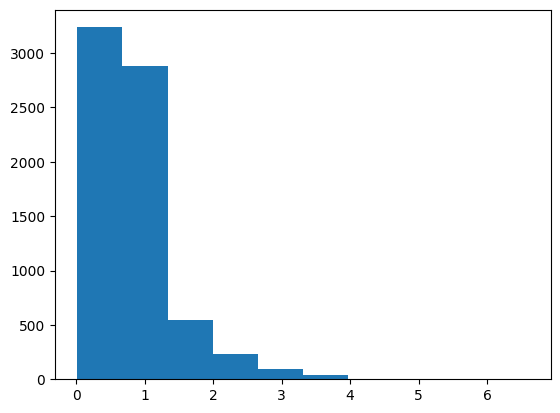

In [21]:
import matplotlib.pyplot as plt

plt.hist(manifest[manifest['Event'] == 'Wheeze']['DurationS'])

In [28]:
manifest['Device'].value_counts()

Device
trunc    36962
steth    31120
Name: count, dtype: int64